# **Publication Tables & Figures 📄**


## **Load libraries and setup**


In [68]:
%load_ext autoreload
%autoreload 2

import json
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.colors import sample_colorscale

from mdner_llm.annotations.build_entity_inventory import collect_entities
from mdner_llm.logger import create_logger
from mdner_llm.visualization.groundtruth import (
    plot_categories_per_text_distribution,
    plot_entity_counts_by_category,
    plot_per_doc_entity_counts,
    plot_text_length_distribution,
    plot_text_similarity_distribution,
)

logger = create_logger()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
%load_ext watermark
%watermark --python --machine
# Python packages versions
%watermark --packages numpy,pandas,plotly

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Python implementation: CPython
Python version       : 3.13.0
IPython version      : 8.13.2

Compiler    : Clang 18.1.8 
OS          : Linux
Release     : 7.0.0-29-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 32
Architecture: 64bit

numpy : 2.4.4
pandas: 2.3.3
plotly: 6.7.0



In [34]:
pd.set_option("display.max_colwidth", None)

In [35]:
def save_figure_for_paper(
    fig: go.Figure,
    output_path: str | Path,
    width: int = 1000,
    height: int = 550,
    scale: int = 1,
) -> None:
    """Save a Plotly figure as a high-resolution image for paper publication."""
    # Ensure target parent directory exists before writing.
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    # Plotly figure export
    if isinstance(fig, go.Figure):
        fig.write_image(str(output_path), width=width, height=height, scale=scale)

    # Matplotlib figure export
    elif isinstance(fig, plt.Figure):
        fig.savefig(str(output_path), dpi=300, bbox_inches="tight")
        plt.close(fig)

## **I. Groundtruth Annotations**


In [36]:
# Collect entities from the groundtruth annotations
df_entities = collect_entities(Path("../data/groundtruth"))
df_entities

2026-09-18 16:09:37 | INFO     | Collecting entities.
2026-09-18 16:09:37 | SUCCESS  | Found 160 JSON files successfully.
2026-09-18 16:09:37 | SUCCESS  | Collected 2519 entities.


,entity,entity_normalized,category,json_file
0,Villin Headpiece,villin headpiece,MOL,figshare_3983526.json
1,6µs,6µs,STIME,figshare_3983526.json
2,ACEMD,acemd,SOFTNAME,figshare_3983526.json
3,CHARMM 27,charmm 27,FFM,figshare_3983526.json
4,2RJY,2rjy,MOL,figshare_3983526.json
...,...,...,...,...
2514,DPPC,dppc,MOL,zenodo_4445375.json
2515,cholesterol,cholesterol,MOL,zenodo_4445375.json
2516,GROMACS,gromacs,SOFTNAME,zenodo_4445375.json
2517,Martini 2,martini 2,FFM,zenodo_4445375.json


In [64]:
# Retrieve the raw text for each document in the groundtruth dataset.
groundtruth_texts = {}
for json_file in df_entities["json_file"].unique():
    file_path = Path("../data/groundtruth") / json_file
    with file_path.open(encoding="utf-8") as f:
        data = json.load(f)
        groundtruth_texts[json_file] = data["raw_text"]

print(f"Retrieved raw text for {len(groundtruth_texts)} documents from groundtruth.\n")
first_file, first_text = next(iter(groundtruth_texts.items()))
print(f"Example document: {first_file}")
print(textwrap.fill(first_text, width=85))

Retrieved raw text for 160 documents from groundtruth.

Example document: figshare_3983526.json
Villin Headpiece Simulations 3 separate simulations each of 6µs concatenated together
are contained herein.  Each trajectory was run with ACEMD using a CHARMM 27 force
field.  The proteins (2RJY) were first solvated to 0.15 mol/L of NaCL and set in a
water box modeled as a TIP3P water model.  Proteins were then equilibrated (conjugate
gradient minimization) and then heated from the crystal structure to unfold.  Folding
simulations were run after a subsequent equilibration. While the simulations do not
find the native folded state,  they sample many partially folded intermediates and
offer insight into the folding pathway of villin headpiece.  Simulations included
here have had the water and ions removed for space considerations and they have been
aligned to remove translation and rotation resulting from diffusion.


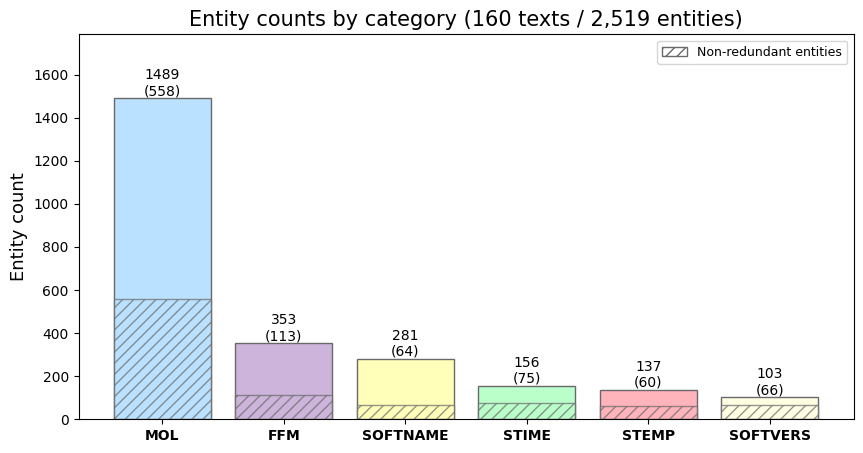

In [37]:
# Plot the entity counts by category.
entity_counts_by_category = plot_entity_counts_by_category(df_entities, logger=logger)
# Save the figure.
save_figure_for_paper(
    entity_counts_by_category,
    output_path="../figures/groundtruth/entity_counts_by_category.pdf",  # or png
)
entity_counts_by_category

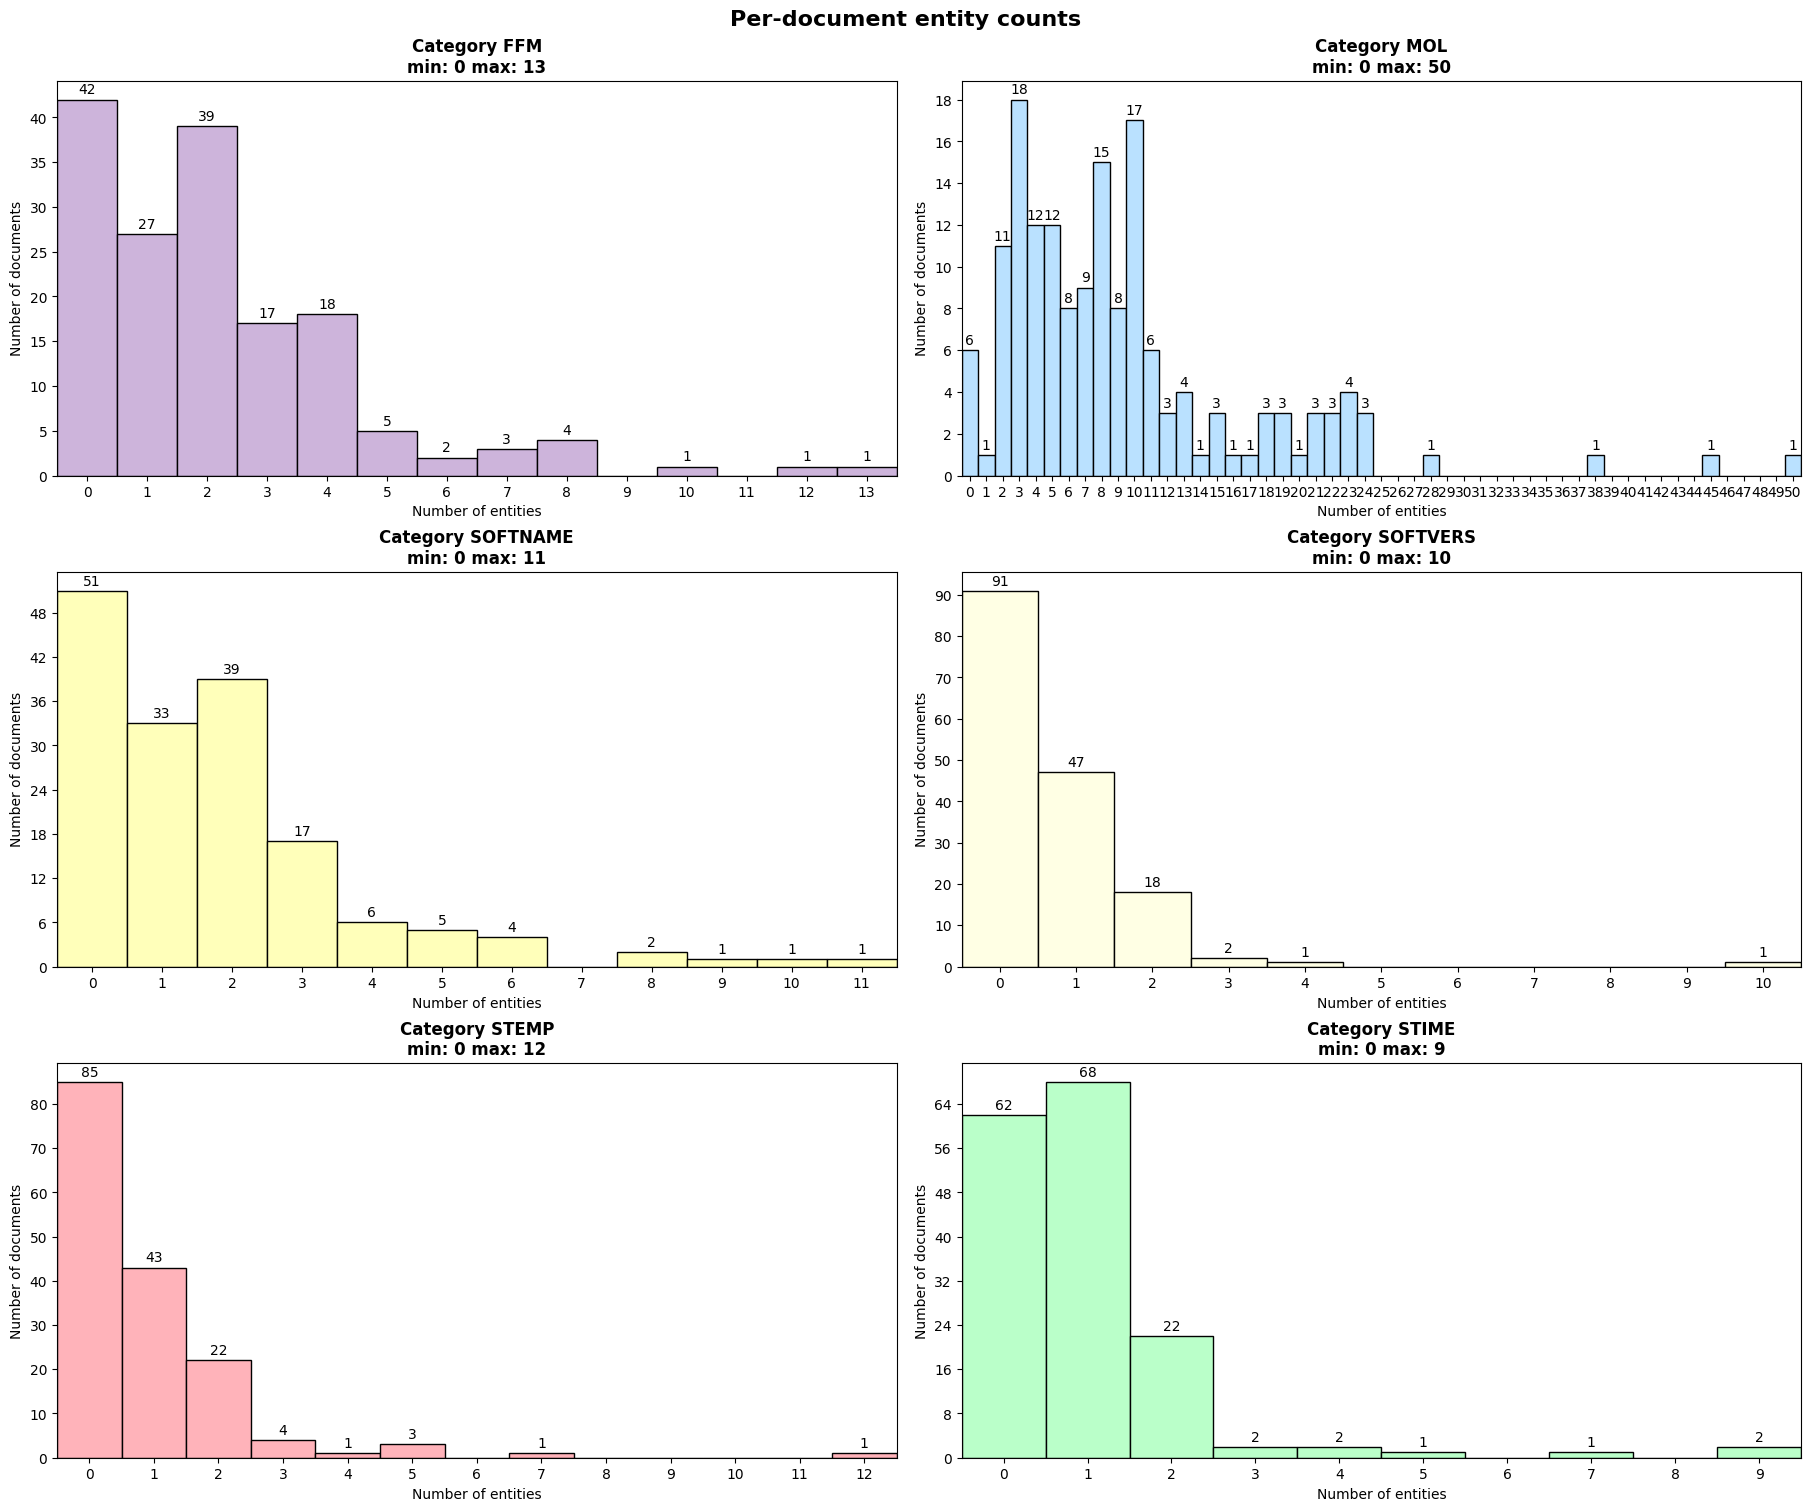

In [38]:
# Plot the category distribution of entities by category.
per_doc_entity_counts = plot_per_doc_entity_counts(
    df_entities,
    non_redundant=False,
)
# Save the figure.
save_figure_for_paper(
    per_doc_entity_counts,
    output_path="../figures/groundtruth/per_doc_entity_counts.pdf",  # or png
)
per_doc_entity_counts

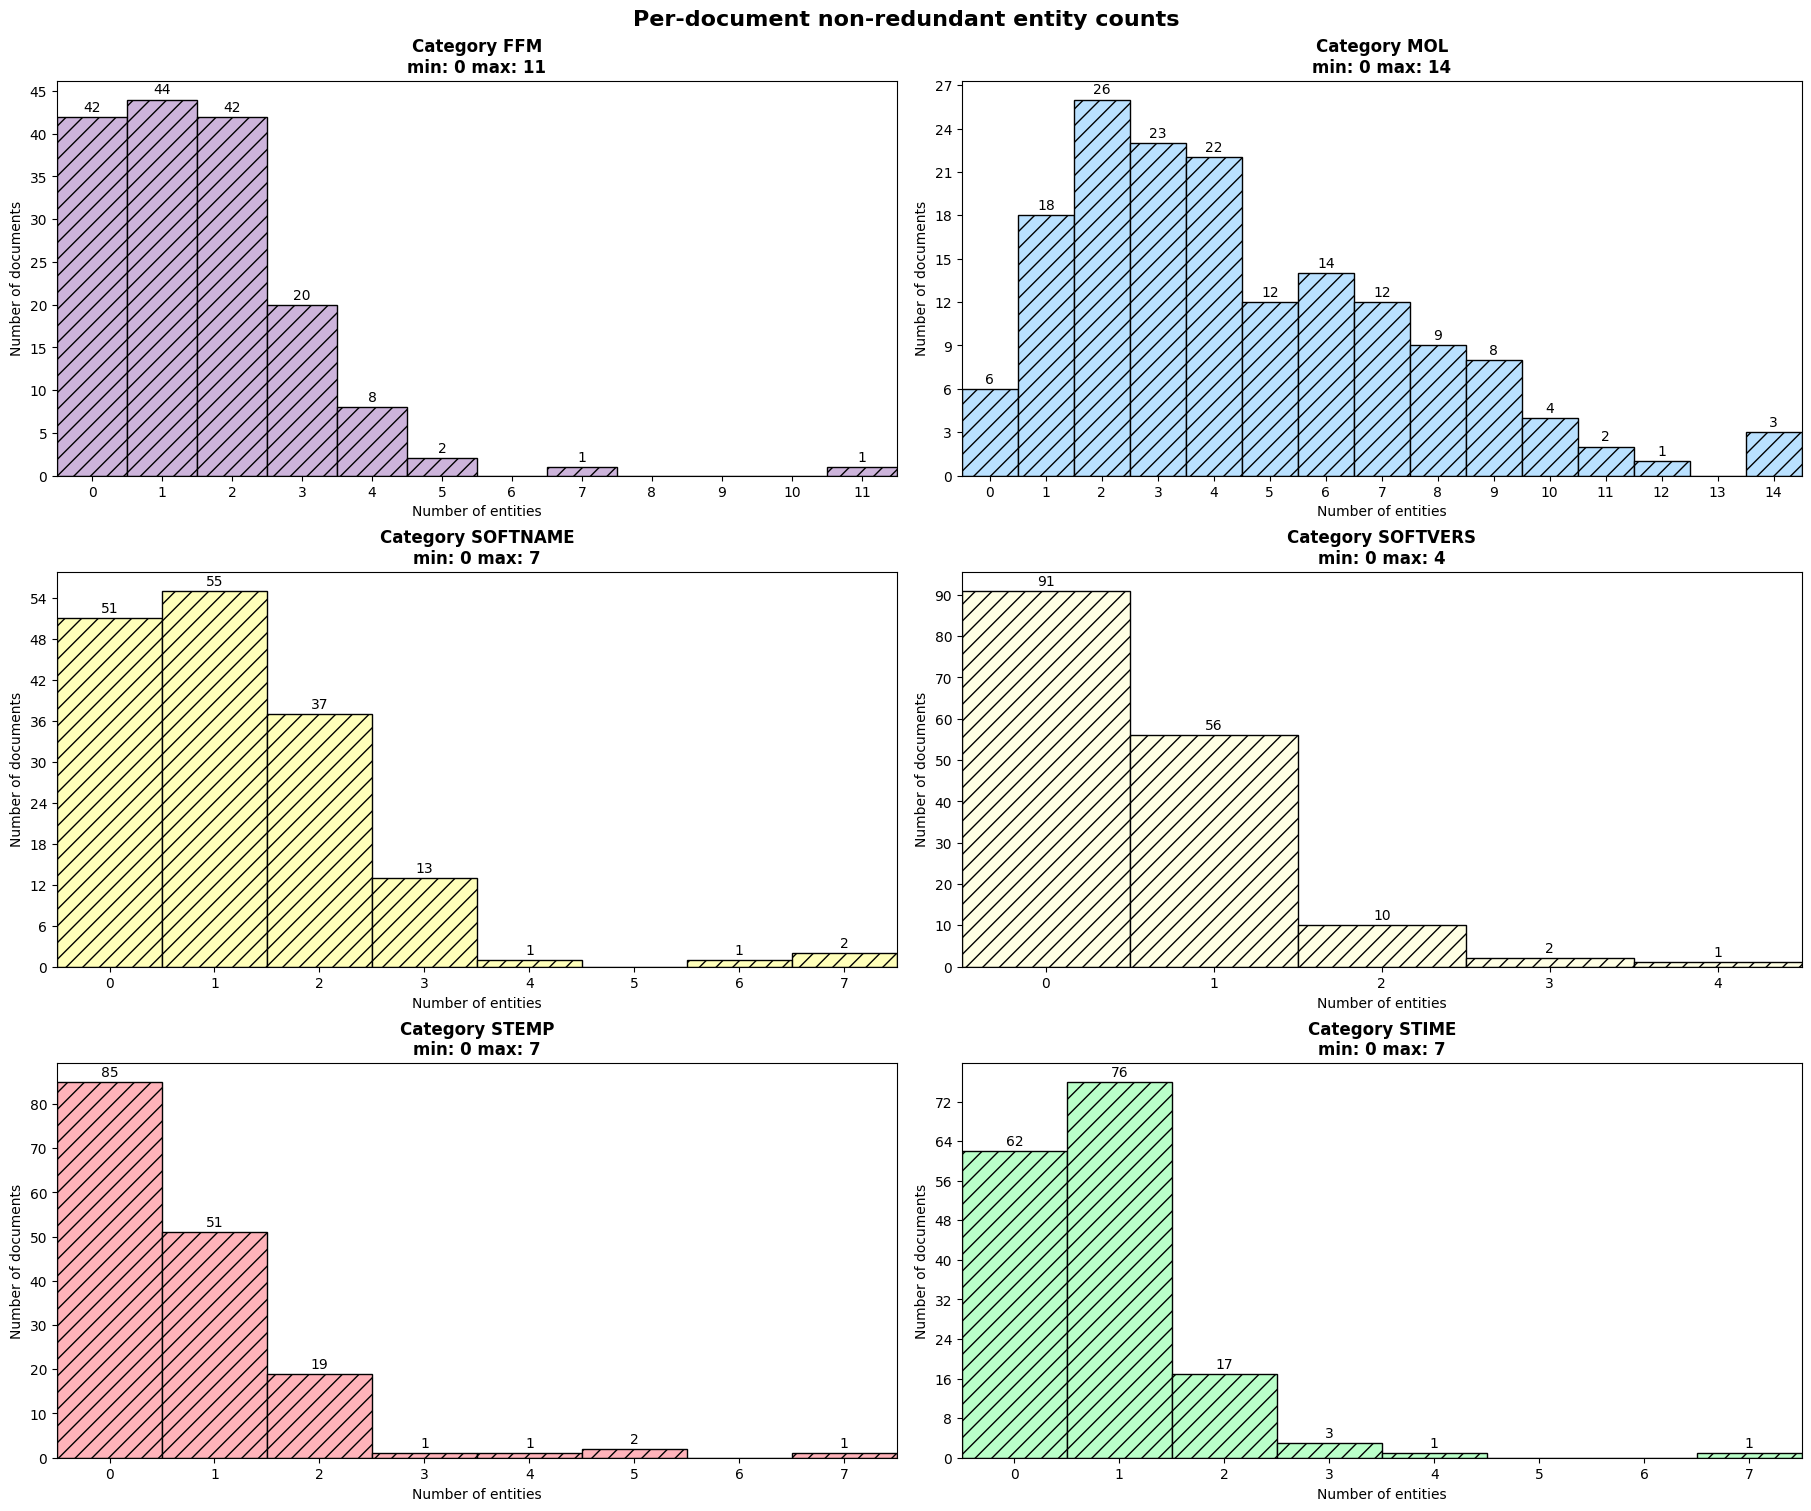

In [39]:
# Plot the category distribution of UNIQUE entities by category.
per_doc_unique_entity_counts = plot_per_doc_entity_counts(
    df_entities,
    non_redundant=True,
)
# Save the figure.
save_figure_for_paper(
    per_doc_unique_entity_counts,
    output_path="../figures/groundtruth/per_doc_unique_entity_counts.pdf",  # or png
)
per_doc_unique_entity_counts

2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_11704443.json'
2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_13655516.json'
2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_14156828.json'
2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_14994624.json'
2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_19405967.json'
2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_21726720.json'
2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_2178850.json'
2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_31390736.json'
2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_3426170.json'
2026-09-18 16:09:38 | WARNING  | Text with low category coverage (1) in 'figshare_8291933.json'
2026-09-18 16:09:38 | WARNING  | 

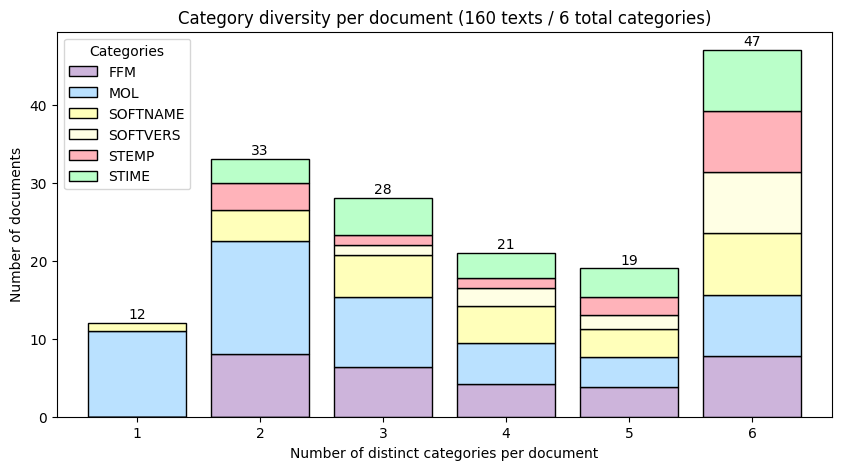

In [40]:
# Plot the category diversity per text.
category_diversity = plot_categories_per_text_distribution(df_entities, logger=logger)
# Save the figure.
save_figure_for_paper(
    category_diversity,
    output_path="../figures/groundtruth/category_diversity_per_text.pdf",  # or png
)
category_diversity

2026-09-18 16:39:48 | WARNING  | Outlier text length in 'zenodo_17391402.json': 595 words
2026-09-18 16:39:48 | WARNING  | Outlier text length in 'zenodo_7007107.json': 1123 words


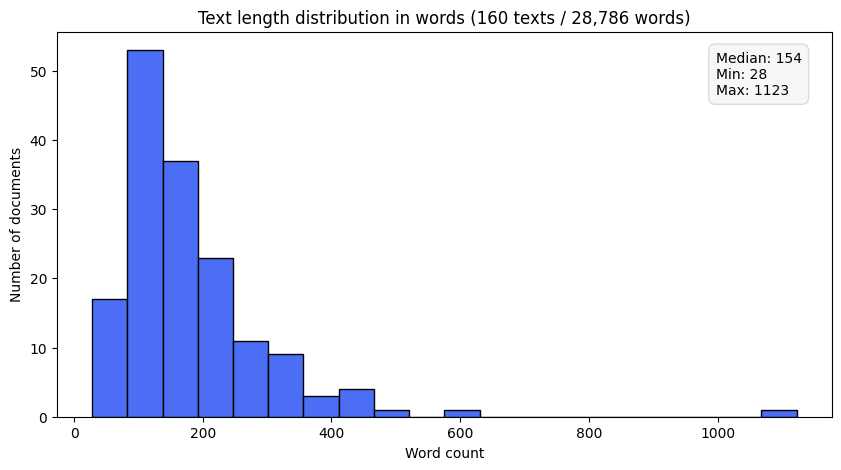

In [67]:
# Plot the text length distribution in words.
text_length_distribution = plot_text_length_distribution(
    groundtruth_texts, logger=logger
)
# Save the figure.
save_figure_for_paper(
    text_length_distribution,
    output_path="../figures/groundtruth/text_length_distribution.pdf",  # or png
)
text_length_distribution

2026-09-18 16:42:19 | INFO     | Most dissimilar pair (0.179): 'zenodo_7107608.json' and 'figshare_8291933.json'
2026-09-18 16:42:19 | INFO     | Median similarity pair (0.484): 'figshare_6575438.json' and 'zenodo_1488094.json'
2026-09-18 16:42:19 | INFO     | Most similar pair (0.992): 'zenodo_51750.json' and 'zenodo_53212.json'
2026-09-18 16:42:19 | WARNING  | Near-duplicate text pair (0.992): 'zenodo_51750.json' and 'zenodo_53212.json'


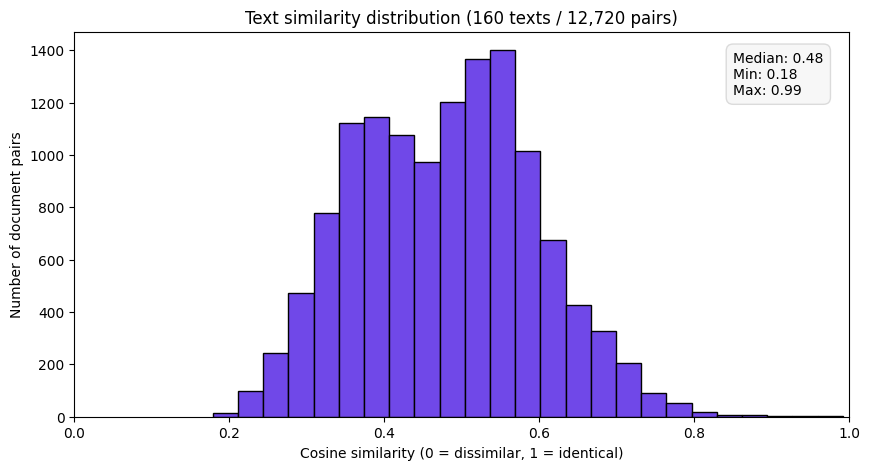

In [69]:
# Plot the text similarity distribution.
text_similarity_distribution = plot_text_similarity_distribution(
    groundtruth_texts, logger=logger
)
# Save the figure.
save_figure_for_paper(
    text_similarity_distribution,
    output_path="../figures/groundtruth/text_similarity_distribution.pdf",  # or png
)
text_similarity_distribution

## **Utilities**


In [7]:
COLOR_PALETTE = [
    "#ffffd9",
    "#edf8b1",
    "#c7e9b4",
    "#7fcdbb",
    "#41b6c4",
    "#1d91c0",
    "#225ea8",
    "#0c2c84",
]


def generate_palette(color_count: int) -> list[str]:
    """Sample a color scale for the requested number of colors.

    Returns
    -------
    list[str]
        A list of hex color codes sampled from the blue-to-purple color scale.
    """
    sample_points = [index / max(color_count - 1, 1) for index in range(color_count)]
    return sample_colorscale(COLOR_PALETTE, sample_points)


def apply_journal_theme(figure: go.Figure, y_axis_title: str) -> None:
    """Apply a clean, publication-ready layout to a Plotly figure."""
    figure.update_layout(
        template="simple_white",
        font={"family": "Arial, Helvetica, sans-serif", "size": 16, "color": "black"},
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin={"l": 70, "r": 30, "t": 70, "b": 90},
    )
    figure.update_yaxes(
        title=y_axis_title.capitalize().replace("_", " "),
        range=[0, 1],
        tickfont={"size": 14},
        title_font={"size": 17},
        showgrid=True,
        gridcolor="rgba(0,0,0,0.08)",
        zeroline=False,
        ticks="outside",
    )
    figure.update_xaxes(
        tickfont={"size": 16},
        showgrid=False,
        tickangle=0,
        ticks="outside",
    )

In [8]:
def plot_benchmark_llm_strategy(
    df: pd.DataFrame,
    human_iaa: float | None,
    metric: str,
    category: str,
    models_to_keep: list[str] | None = None,
    title: str | None = None,
) -> go.Figure:
    """Plot the performance of different LLM strategies for a given metric.

    Returns
    -------
    go.Figure
        A Plotly figure object representing the benchmark performance of LLM strategies.
    """
    # Define mapping dictionary for strategy display labels.
    combo_labels = {
        "no_instructor_no_guidelines": "No instructor<br>no guideline",
        "no_instructor_with_guidelines": "No instructor<br>with guideline",
        "with_instructor_no_guidelines": "With instructor<br>no guideline",
        "with_instructor_with_guidelines": "With instructor<br>with guideline",
    }
    # Filter dataset by selected category.
    data = df[df["category"] == category].copy()
    # Filter by specific models if provided, otherwise keep all models.
    if models_to_keep is not None and len(models_to_keep) > 0:
        data = data[data["Name"].isin(models_to_keep)]
    # Construct strategy key matching combo_labels dictionary keys.
    inst_part = (
        data["Framework"]
        .astype(str)
        .str.lower()
        .apply(lambda x: "with_instructor" if "instructor" in x else "no_instructor")
    )
    guide_part = data["With_Guideline"].map(
        {True: "with_guidelines", False: "no_guidelines"}
    )
    data["combo_key"] = inst_part + "_" + guide_part
    # Map raw strategy keys into formatted multi-line strings.
    data["strategy"] = data["combo_key"].map(combo_labels)
    # Filter strategies maintaining predefined order.
    strategies = [lbl for lbl in combo_labels.values() if lbl in set(data["strategy"])]
    # Directly assign input metric column.
    metric_col = metric
    # Aggregate duplicates by model and strategy to allow reindexing.
    data = data.groupby(["Name", "strategy"], as_index=False)[metric_col].mean()
    # Compute maximum value per strategy for bold highlighting.
    max_per_strat = data.groupby("strategy")[metric_col].apply(
        lambda s: s.round(2).max()
    )
    models = data["Name"].unique()
    # Generate distinct colors for each unique model.
    palette = generate_palette(len(models))
    fig = go.Figure()
    # Add grouped bars with journal styling and highlighted values.
    for model, color in zip(models, palette, strict=False):
        sub = data[data["Name"] == model].set_index("strategy").reindex(strategies)
        text_labels = [
            f"<b>{value:.2f}</b>"
            if round(value, 2) == max_per_strat.get(strat)
            else f"{value:.2f}"
            for strat, value in sub[metric_col].items()
        ]
        fig.add_bar(
            x=strategies,
            y=sub[metric_col],
            name=model,
            marker={"color": color, "line": {"color": "white", "width": 1}},
            text=text_labels,
            textposition="outside",
            textfont={"size": 13},
        )
    # Add baseline human IAA threshold line if provided.
    if human_iaa is not None:
        fig.add_hline(
            y=human_iaa,
            line={"color": "#555555", "dash": "dash", "width": 1.5},
            annotation_text="Human IAA",
            annotation_position="right",
            annotation_font={"size": 14, "color": "#555555"},
        )
    # Format y-axis title by replacing underscores with spaces.
    clean_y_title = metric_col.replace("_", " ")
    apply_journal_theme(fig, clean_y_title)
    # Disable hover interaction and place title properly above legend.
    fig.update_layout(
        hovermode=False,
        title={
            "text": title,
            "x": 0.5,
            "y": 0.98,
            "xanchor": "center",
            "yanchor": "top",
        }
        if title
        else None,
        bargroupgap=0.08,
        legend={
            "orientation": "h",
            "y": 1.10,
            "x": 0.5,
            "xanchor": "center",
            "yanchor": "bottom",
            "font": {"size": 15},
        },
        margin={"r": 100, "t": 140 if title else 80},
    )
    return fig

In [9]:
def compute_benchmark_stats(
    df: pd.DataFrame,
    metric: str = "F1_with_no_hallucination",
    category: str = "OVERALL_MICRO",
    models_to_keep: list[str] | None = None,
) -> dict:
    """Compute benchmark statistics for a given metric and category."""
    data = df[df["category"] == category].copy()
    # Filter by specific models if provided, otherwise keep all models.
    if models_to_keep is not None and len(models_to_keep) > 0:
        data = data[data["Name"].isin(models_to_keep)]
    # Build clear strategy identifiers.
    inst = np.where(
        # Map "Framework" column to "with_instructor" or "no_instructor".
        data["Framework"].str.contains("instructor", case=False, na=False),
        "with_instructor",
        "no_instructor",
    )
    # Map "With_Guideline" column to "with_guidelines" or "no_guidelines".
    guide = np.where(data["With_Guideline"], "with_guidelines", "no_guidelines")
    data["strategy"] = inst + "_" + guide
    # Strategy and model rankings for the primary metric.
    agg = data.groupby(["Name", "strategy"], as_index=False)[metric].mean()
    strat_means = agg.groupby("strategy")[metric].mean().sort_values(ascending=False)
    model_means = agg.groupby("Name")[metric].mean().sort_values(ascending=False)
    best_row = agg.loc[agg[metric].idxmax()]
    best_combo = (best_row["Name"], best_row["strategy"], best_row[metric])
    strat_gap = strat_means.iloc[0] - strat_means.iloc[-1]
    # Display primary benchmark metrics.
    print(f"=== Benchmark Stats: {metric} ({category}) ===")
    print(f"Best Strategy : {strat_means.index[0]} ({strat_means.iloc[0]:.2f})")
    print(
        f"Worst Strategy: {strat_means.index[-1]} ({strat_means.iloc[-1]:.2f}) |"
        f" Gap: {strat_gap:+.2f}"
    )
    print(f"Best Combo    : {best_combo[0]} + {best_combo[1]} ({best_combo[2]:.2f})")
    print(f"Best Model    : {model_means.index[0]} ({model_means.iloc[0]:.2f})\n")
    # Display rates broken down by strategy with specific ranking orders.
    rate_configs = [
        (
            "Correct_format_(%)",
            "Correct format rates",
            False,
        ),  # descending (best first)
        ("Hallucinations_(%)", "Hallucination rates", True),  # ascending (best first)
    ]
    for col, title, ascending in rate_configs:
        if col in data.columns:
            print(f"=== {title} ===")
            rates = (
                data.groupby("strategy")[col].mean().sort_values(ascending=ascending)
            )
            for strat, val in rates.items():
                print(f"  * {strat}: {val:.0f}%")
            print()

In [10]:
def save_figure_for_paper(
    fig: go.Figure,
    output_path: str | Path,
    width: int = 1000,
    height: int = 550,
    scale: int = 1,
) -> None:
    """Save a Plotly figure as a high-resolution image for paper publication."""
    # Ensure target parent directory exists before writing.
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    # Export static high-dpi image suited for camera-ready submission.
    fig.write_image(str(output_path), width=width, height=height, scale=scale)

In [11]:
def get_base_family(name: str) -> str:
    """Normalize model display or checkpoint name.

    Returns
    -------
    str
        The base architecture family name, with any fine-tuning suffix removed.
    """
    clean_name = name.split("/")[-1].lower()
    return clean_name.replace("-finetuned", "").replace("_finetuned", "")


def get_generation_group(family_name: str) -> str:
    """Map architecture family name to its broad GLiNER generation group.

    Returns
    -------
    str
        One of 'GLiNER-BioMed', 'GLiNER2', or 'GLiNER2.5'.
    """
    if "biomed" in family_name:
        return "GLiNER-BioMed"
    if "gliner2.5" in family_name:
        return "GLiNER2.5"
    return "GLiNER2"


def plot_benchmark_gliner_models(
    df: pd.DataFrame,
    human_iaa: float | None,
    metric: str = "F1",
    category: str = "OVERALL_MICRO",
) -> go.Figure:
    data = df[df["category"] == category].copy()

    # Base model family, generation group, and fine-tuning flag
    data["base_family"] = data["Name"].apply(get_base_family)
    data["generation_group"] = data["base_family"].apply(get_generation_group)
    data["is_finetuned"] = data["Name"].str.contains("finetuned", case=False, na=False)
    data["display_label"] = data["Name"].apply(lambda s: s.split("/")[-1])

    # Palette réajustée : GLiNER-BioMed passe sur un terracotta/ambre contrasté
    family_palette = {
        "gliner-biomed-base-v1.0": "#b0bec5",  # Terracotta lumineux
        "gliner-biomed-large-v1.0": "#78909c",  # Rouille / ambre profond
        "gliner2-base-v1": "#56c596",
        "gliner2-large-v1": "#2a9d8f",
        "gliner2.5-base-v1": "#1d3557",
        "gliner2.5-large-v1": "#0b1b3d",
    }
    unique_families = list(dict.fromkeys(data["base_family"]))
    default_palette = generate_palette(len(unique_families))
    family_to_color = {
        fam: family_palette.get(fam, default_palette[i])
        for i, fam in enumerate(unique_families)
    }

    # Tri côte-à-côte
    data["family_order"] = data["base_family"].map(
        {fam: i for i, fam in enumerate(unique_families)}
    )
    data = data.sort_values(
        by=["family_order", "is_finetuned"], ascending=[True, True]
    ).reset_index(drop=True)
    data["x_axis_label"] = data["display_label"]

    figure = go.Figure()

    # 1. Barres
    for _, row in data.iterrows():
        is_ft = row["is_finetuned"]
        val = row[metric]
        color = family_to_color[row["base_family"]]
        x_label = row["x_axis_label"]

        figure.add_bar(
            x=[x_label],
            y=[val],
            name=row["Name"],
            marker={
                "color": color,
                "line": {"color": "white", "width": 1.2},
                "pattern": {
                    "shape": "/" if is_ft else "",
                    "solidity": 0.35,
                    "fgcolor": "white",
                },
            },
            text=[f"{val:.2f}"],
            textposition="outside",
            textfont={"size": 13},
            showlegend=False,
        )

    # 2. Légende
    generation_order = ["GLiNER-BioMed", "GLiNER2", "GLiNER2.5"]
    first_category_x = data["x_axis_label"].iloc[0]
    for group in generation_order:
        fam_matches = data[data["generation_group"] == group]
        if not fam_matches.empty:
            rep_family = fam_matches.iloc[0]["base_family"]
            rep_color = family_to_color[rep_family]
            figure.add_trace(
                go.Scatter(
                    x=[first_category_x],
                    y=[None],
                    mode="markers",
                    name=group,
                    marker={"size": 13, "symbol": "square", "color": rep_color},
                    showlegend=True,
                )
            )

    # 3. Connecteurs et annotations delta
    x_positions = {label: i for i, label in enumerate(data["x_axis_label"])}
    for family in unique_families:
        fam_subset = data[data["base_family"] == family]
        base_rows = fam_subset[~fam_subset["is_finetuned"]]
        ft_rows = fam_subset[fam_subset["is_finetuned"]]

        if not base_rows.empty and not ft_rows.empty:
            base_row = base_rows.iloc[0]
            ft_row = ft_rows.iloc[0]

            x_base = base_row["x_axis_label"]
            x_ft = ft_row["x_axis_label"]

            y_base = base_row[metric]
            y_ft = ft_row[metric]
            delta = y_ft - y_base

            # Le pont monte au maximum à 0.98
            h_bridge = min(max(y_base, y_ft) + 0.08, 0.98)

            path = (
                f"M {x_base},{y_base} "
                f"L {x_base},{h_bridge} "
                f"L {x_ft},{h_bridge} "
                f"L {x_ft},{y_ft}"
            )
            figure.add_shape(
                type="path",
                path=path,
                fillcolor="rgba(0,0,0,0)",
                line={"color": "#111111", "width": 1.2},
            )

            delta_sign = "+" if delta >= 0 else ""
            center_x = (x_positions[x_base] + x_positions[x_ft]) / 2
            figure.add_annotation(
                x=center_x,
                y=h_bridge + 0.04,
                text=f"<b>{delta_sign}{delta:.2f}</b>",
                showarrow=False,
                font={"size": 13, "color": "#111111"},
                align="center",
                yanchor="bottom",  # Pose le bas du texte sur le pont
                yshift=4,  # Décale de 4 pixels vers le haut (hors contrainte d'axe)
            )

    # 4. Human IAA
    if human_iaa is not None:
        figure.add_hline(
            y=human_iaa,
            line={"color": "#555555", "dash": "dash", "width": 1.5},
            annotation_text="Human IAA",
            annotation_position="right",
            annotation_font={"size": 14, "color": "#555555"},
        )

    apply_journal_theme(figure, metric)
    figure.update_layout(
        hovermode=False,
        margin={"l": 80, "r": 140, "t": 90, "b": 150},
        xaxis={
            "type": "category",
            "tickangle": -25,
        },
        yaxis={
            "range": [0, 1],  # Espace vertical pour afficher le +0.38
        },
        legend={
            "orientation": "h",
            "yanchor": "bottom",
            "y": 1.02,
            "xanchor": "center",
            "x": 0.5,
            "font": {"size": 15},
        },
    )

    return figure

## **Figure 1 - Effect of Prompt Strategy across all version of Claude Opus LLM**


In [12]:
# Load the data
opus_df = df = pd.read_csv("../results/llm_opus/evaluation/benchmark_strategies.csv")
opus_df

,Inference_date,Name,Framework,With_Guideline,category,Number_of_texts_with_category,Correct_format_(%),Hallucinations_(%),Precision,Precision_with_no_hallucination,...,F1,F1_with_no_hallucination,Fbeta_0.5,Fbeta_0.5_with_no_hallucination,Cost_by_entity_($),Inference_time_by_entity_(s),Number_of_predicted_entities,Cost_total_($),Inference_time_total_(s),Inference_time_total_(hh:mm:ss)
0,NaN,anthropic/claude-opus-4,noframework,False,FFM,118.0,94.117647,0.0,0.896104,0.896104,...,0.864301,0.864301,0.883106,0.883106,NaN,NaN,231.0,NaN,NaN,NaN
1,NaN,anthropic/claude-opus-4,noframework,False,MOL,154.0,93.548387,0.0,0.823214,0.823214,...,0.723137,0.723137,0.780034,0.780034,NaN,NaN,560.0,NaN,NaN,NaN
2,NaN,anthropic/claude-opus-4,noframework,False,SOFTNAME,109.0,94.782609,0.0,0.857143,0.857143,...,0.850394,0.850394,0.854430,0.854430,NaN,NaN,189.0,NaN,NaN,NaN
3,NaN,anthropic/claude-opus-4,noframework,False,SOFTVERS,69.0,91.304348,0.0,0.929577,0.929577,...,0.840764,0.840764,0.891892,0.891892,NaN,NaN,71.0,NaN,NaN,NaN
4,NaN,anthropic/claude-opus-4,noframework,False,STEMP,75.0,97.402597,0.0,0.953704,0.953704,...,0.932127,0.932127,0.944954,0.944954,NaN,NaN,108.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,NaN,anthropic/claude-opus-5,instructor,True,OVERALL_MACRO,623.0,99.893162,0.0,0.889366,0.889366,...,0.900116,0.900116,0.893417,0.893417,NaN,NaN,1531.0,0.0,0.0,NaN
276,NaN,anthropic/claude-opus-5,noframework,False,OVERALL_MICRO,623.0,99.641397,0.0,0.835791,0.835791,...,0.838038,0.838038,0.836688,0.836688,NaN,NaN,1492.0,0.0,0.0,NaN
277,NaN,anthropic/claude-opus-5,noframework,False,OVERALL_MACRO,623.0,99.641397,0.0,0.845212,0.845212,...,0.863132,0.863132,0.851621,0.851621,NaN,NaN,1492.0,0.0,0.0,NaN
278,NaN,anthropic/claude-opus-5,noframework,True,OVERALL_MICRO,623.0,98.615771,0.0,0.879404,0.879404,...,0.877027,0.877027,0.878452,0.878452,NaN,NaN,1476.0,0.0,0.0,NaN


In [13]:
for metric in [
    "F1_with_no_hallucination",
    "Precision_with_no_hallucination",
    "Recall",
]:
    opus_benchmark = plot_benchmark_llm_strategy(
        opus_df,
        human_iaa=0.76,
        metric=metric,
        category="OVERALL_MICRO",
        title="Benchmarking all version of Claude Opus LLM Strategies "
        "for NER Performance",
    )
    save_figure_for_paper(opus_benchmark, f"../figures/benchmark_opus_{metric}.pdf")
    save_figure_for_paper(opus_benchmark, f"../figures/benchmark_opus_{metric}.png")
    opus_benchmark.show()

In [14]:
compute_benchmark_stats(
    opus_df, metric="F1_with_no_hallucination", category="OVERALL_MICRO"
)

=== Benchmark Stats: F1_with_no_hallucination (OVERALL_MICRO) ===
Best Strategy : with_instructor_with_guidelines (0.86)
Worst Strategy: no_instructor_no_guidelines (0.81) | Gap: +0.04
Best Combo    : anthropic/claude-opus-5 + no_instructor_with_guidelines (0.88)
Best Model    : anthropic/claude-opus-5 (0.86)

=== Correct format rates ===
  * with_instructor_with_guidelines: 100%
  * with_instructor_no_guidelines: 99%
  * no_instructor_no_guidelines: 99%
  * no_instructor_with_guidelines: 98%

=== Hallucination rates ===
  * no_instructor_no_guidelines: 0%
  * with_instructor_no_guidelines: 0%
  * with_instructor_with_guidelines: 0%
  * no_instructor_with_guidelines: 0%



## **Figure 2 - Effect of Prompt Strategy on High-Capacity SOTA LLMs vs Lightweight LLMs**


In [15]:
# Load the data
strategies_df = df = pd.read_csv("../results/llm/evaluation/benchmark_strategies.csv")
strategies_df

,Inference_date,Name,Framework,With_Guideline,category,Number_of_texts_with_category,Correct_format_(%),Hallucinations_(%),Precision,Precision_with_no_hallucination,...,F1,F1_with_no_hallucination,Fbeta_0.5,Fbeta_0.5_with_no_hallucination,Cost_by_entity_($),Inference_time_by_entity_(s),Number_of_predicted_entities,Cost_total_($),Inference_time_total_(s),Inference_time_total_(hh:mm:ss)
0,NaN,deepseek/deepseek-v4-pro,instructor,False,FFM,118.0,100.000000,0.000000,0.918803,0.918803,...,0.892116,0.892116,0.907939,0.907939,NaN,NaN,234.0,NaN,NaN,NaN
1,NaN,deepseek/deepseek-v4-pro,instructor,False,MOL,154.0,100.000000,0.000000,0.822186,0.822186,...,0.759036,0.759036,0.795706,0.795706,NaN,NaN,613.0,NaN,NaN,NaN
2,NaN,deepseek/deepseek-v4-pro,instructor,False,SOFTNAME,109.0,100.000000,0.000000,0.869565,0.869565,...,0.902256,0.902256,0.882353,0.882353,NaN,NaN,207.0,NaN,NaN,NaN
3,NaN,deepseek/deepseek-v4-pro,instructor,False,SOFTVERS,69.0,100.000000,0.000000,0.876543,0.876543,...,0.850299,0.850299,0.865854,0.865854,NaN,NaN,81.0,NaN,NaN,NaN
4,NaN,deepseek/deepseek-v4-pro,instructor,False,STEMP,75.0,100.000000,0.000000,0.916667,0.916667,...,0.895928,0.895928,0.908257,0.908257,NaN,NaN,108.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,NaN,deepseek/deepseek-v4-flash-0731,instructor,False,SOFTVERS,69.0,98.571429,2.564103,0.897436,0.921053,...,0.853659,0.864198,0.879397,0.897436,NaN,NaN,78.0,NaN,NaN,NaN
316,NaN,deepseek/deepseek-v4-flash-0731,instructor,False,STEMP,75.0,98.717949,8.695652,0.782609,0.857143,...,0.789474,0.825688,0.785340,0.844278,NaN,NaN,115.0,NaN,NaN,NaN
317,NaN,deepseek/deepseek-v4-flash-0731,instructor,False,STIME,98.0,99.009901,0.609756,0.713415,0.717791,...,0.795918,0.798635,0.744275,0.748082,NaN,NaN,164.0,NaN,NaN,NaN
318,2026-09-07T15:08:49,deepseek/deepseek-v4-flash-0731,instructor,False,OVERALL_MICRO,160.0,98.750000,2.043796,0.837956,0.854803,...,0.804485,0.812168,0.824239,0.837223,0.000105,11.874965,1370.0,0.226296,25531.17435,07:05:31


In [16]:
for metric in [
    "F1_with_no_hallucination",
    "Precision_with_no_hallucination",
    "Recall",
]:
    llm_benchmark = plot_benchmark_llm_strategy(
        strategies_df,
        human_iaa=0.76,
        metric=metric,
        category="OVERALL_MICRO",
        models_to_keep=[
            "deepseek/deepseek-v4-pro-0813",
            "anthropic/claude-fable-5",
            "anthropic/claude-fable-5.1",
            "openai/gpt-5.6-sol",
            "moonshotai/kimi-k3",
        ],
        title="Benchmarking High-Capacity SOTA LLMs strategies for NER Performance",
    )
    save_figure_for_paper(
        llm_benchmark, f"../figures/benchmark_strategies_sota_{metric}.pdf"
    )
    save_figure_for_paper(
        llm_benchmark, f"../figures/benchmark_strategies_sota_{metric}.png"
    )
    llm_benchmark.show()

KeyboardInterrupt: 

In [ ]:
compute_benchmark_stats(
    strategies_df,
    metric="F1_with_no_hallucination",
    category="OVERALL_MICRO",
    models_to_keep=[
        "deepseek/deepseek-v4-pro-0813",
        "anthropic/claude-fable-5",
        "openai/gpt-5.6-sol",
        "moonshotai/kimi-k3",
    ],
)


=== Benchmark Stats: F1_with_no_hallucination (OVERALL_MICRO) ===
Best Strategy : no_instructor_with_guidelines (0.84)
Worst Strategy: with_instructor_no_guidelines (0.80) | Gap: +0.03
Best Combo    : openai/gpt-5.6-sol + no_instructor_with_guidelines (0.88)
Best Model    : moonshotai/kimi-k3 (0.86)

=== Correct format rates ===
  * no_instructor_no_guidelines: 95%
  * with_instructor_no_guidelines: 92%
  * no_instructor_with_guidelines: 91%
  * with_instructor_with_guidelines: 91%

=== Hallucination rates ===
  * no_instructor_with_guidelines: 0%
  * no_instructor_no_guidelines: 0%
  * with_instructor_with_guidelines: 0%
  * with_instructor_no_guidelines: 0%



In [ ]:
for metric in [
    "F1_with_no_hallucination",
    "Precision_with_no_hallucination",
    "Recall",
]:
    llm_benchmark = plot_benchmark_llm_strategy(
        strategies_df,
        human_iaa=0.76,
        metric=metric,
        category="OVERALL_MICRO",
        models_to_keep=[
            "google/gemma-4-31b-it",
            "qwen/qwen3.8-27b",
            "openai/gpt-oss-20b",
            "deepseek/deepseek-v4-flash-0731",
        ],
        title="Benchmarking Lightweight LLMs (< 50B Parameters) Strategies"
        " for NER Performance",
    )
    save_figure_for_paper(
        llm_benchmark, f"../figures/benchmark_strategies_small_{metric}.pdf"
    )
    save_figure_for_paper(
        llm_benchmark, f"../figures/benchmark_strategies_small_{metric}.png"
    )
    llm_benchmark.show()

In [ ]:
compute_benchmark_stats(
    strategies_df,
    metric="F1_with_no_hallucination",
    category="OVERALL_MICRO",
    models_to_keep=[
        "google/gemma-4-31b-it",
        "qwen/qwen3.8-27b",
        "openai/gpt-oss-20b",
        "deepseek/deepseek-v4-flash-0731",
    ],
)


=== Benchmark Stats: F1_with_no_hallucination (OVERALL_MICRO) ===
Best Strategy : with_instructor_with_guidelines (0.84)
Worst Strategy: no_instructor_no_guidelines (0.69) | Gap: +0.15
Best Combo    : qwen/qwen3.8-27b + with_instructor_with_guidelines (0.88)
Best Model    : qwen/qwen3.8-27b (0.83)

=== Correct format rates ===
  * with_instructor_with_guidelines: 100%
  * with_instructor_no_guidelines: 99%
  * no_instructor_with_guidelines: 89%
  * no_instructor_no_guidelines: 80%

=== Hallucination rates ===
  * no_instructor_with_guidelines: 0%
  * no_instructor_no_guidelines: 1%
  * with_instructor_no_guidelines: 1%
  * with_instructor_with_guidelines: 2%



## **Figure 4 - Closing the Gap with Frontier Models: Effect of Consensus Aggregation on Small LLMs**


In [ ]:
consensus_df = pd.read_csv("../results/llm/evaluation/benchmark_models.csv")
consensus_df

,Inference_date,Name,category,Number_of_texts_with_category,Correct_format_(%),Hallucinations_(%),Precision,Precision_with_no_hallucination,Recall,F1,F1_with_no_hallucination,Fbeta_0.5,Fbeta_0.5_with_no_hallucination,Cost_by_entity_($),Inference_time_by_entity_(s),Number_of_predicted_entities,Cost_total_($),Inference_time_total_(s),Inference_time_total_(hh:mm:ss)
0,NaN,meta-llama/llama-3.1-8b-instruct,FFM,118.0,98.684211,4.792332,0.594249,0.624161,0.750000,0.663102,0.681319,0.620000,0.645833,NaN,NaN,313.0,NaN,NaN,NaN
1,NaN,meta-llama/llama-3.1-8b-instruct,MOL,154.0,98.742138,3.254438,0.596154,0.616208,0.563636,0.579439,0.588751,0.589354,0.604923,NaN,NaN,676.0,NaN,NaN,NaN
2,NaN,meta-llama/llama-3.1-8b-instruct,SOFTNAME,109.0,99.328859,10.236220,0.551181,0.614035,0.729167,0.627803,0.666667,0.579470,0.634058,NaN,NaN,254.0,NaN,NaN,NaN
3,NaN,meta-llama/llama-3.1-8b-instruct,SOFTVERS,69.0,100.000000,8.823529,0.588235,0.645161,0.697674,0.638298,0.670391,0.607287,0.655022,NaN,NaN,102.0,NaN,NaN,NaN
4,NaN,meta-llama/llama-3.1-8b-instruct,STEMP,75.0,100.000000,12.209302,0.517442,0.589404,0.787611,0.624561,0.674242,0.555556,0.620642,NaN,NaN,172.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,NaN,consensus_google_gemma-4-31b-it_openai_gpt-oss...,SOFTVERS,69.0,100.000000,0.000000,0.960526,0.960526,0.848837,0.901235,0.901235,0.935897,0.935897,NaN,NaN,76.0,NaN,NaN,NaN
196,NaN,consensus_google_gemma-4-31b-it_openai_gpt-oss...,STEMP,75.0,100.000000,0.000000,0.954955,0.954955,0.938053,0.946429,0.946429,0.951526,0.951526,NaN,NaN,111.0,NaN,NaN,NaN
197,NaN,consensus_google_gemma-4-31b-it_openai_gpt-oss...,STIME,98.0,100.000000,0.000000,0.876812,0.876812,0.930769,0.902985,0.902985,0.887097,0.887097,NaN,NaN,138.0,NaN,NaN,NaN
198,2026-08-07T02:17:12,consensus_google_gemma-4-31b-it_openai_gpt-oss...,OVERALL_MICRO,160.0,100.000000,0.226074,0.912585,0.914653,0.816038,0.861615,0.862536,0.891490,0.893068,0.003863,52.475825,1327.0,5.219181,70894.83892,19:41:34


In [ ]:
print(consensus_df)

          Inference_date                                               Name  \
0                    NaN                   meta-llama/llama-3.1-8b-instruct   
1                    NaN                   meta-llama/llama-3.1-8b-instruct   
2                    NaN                   meta-llama/llama-3.1-8b-instruct   
3                    NaN                   meta-llama/llama-3.1-8b-instruct   
4                    NaN                   meta-llama/llama-3.1-8b-instruct   
..                   ...                                                ...   
195                  NaN  consensus_google_gemma-4-31b-it_openai_gpt-oss...   
196                  NaN  consensus_google_gemma-4-31b-it_openai_gpt-oss...   
197                  NaN  consensus_google_gemma-4-31b-it_openai_gpt-oss...   
198  2026-08-07T02:17:12  consensus_google_gemma-4-31b-it_openai_gpt-oss...   
199  2026-08-07T02:17:12  consensus_google_gemma-4-31b-it_openai_gpt-oss...   

          category  Number_of_texts_with_category  

In [ ]:
def plot_benchmark_consensus_strategy(
    df: pd.DataFrame,
    metric: str,
    human_iaa: float | None = None,
    category: str = "OVERALL_MICRO",
    models_to_keep: list[str] | None = None,
    title: str | None = None,
) -> go.Figure:
    """Build the standalone-models-vs-consensus figure from evaluation table.

    Returns
    -------
    go.Figure
        A Plotly figure object representing the benchmark performance of standalone
        models versus consensus models for a given metric and category.
    """
    # Filter dataset for the selected evaluation category
    sub_df = df[df["category"] == category].copy()
    # Separate standalone models from consensus models
    is_consensus = sub_df["Name"].str.startswith("consensus")
    if models_to_keep:
        solo_df = sub_df[sub_df["Name"].isin(models_to_keep)]
    else:
        solo_df = sub_df[~is_consensus]
    cons_df = sub_df[is_consensus]

    # Clean model identifiers for better readability on x-axis
    def clean_name(name: str) -> str:
        return name.split("/")[-1] if "/" in name else name

    # Prepare bar chart labels and corresponding metric values
    solo_labels = [clean_name(n) for n in solo_df["Name"]]
    solo_scores = solo_df[metric].tolist()
    cons_labels = ["Consensus" for _ in range(len(cons_df))]
    cons_scores = cons_df[metric].tolist()
    labels = solo_labels + cons_labels
    scores = solo_scores + cons_scores
    # Initialize the Plotly figure with bar traces
    figure = go.Figure(
        go.Bar(
            x=labels,
            y=scores,
            marker_color=generate_palette(len(labels)),
            marker_line={"color": "white", "width": 1},
            text=[f"{s:.2f}" for s in scores],
            textposition="outside",
            textfont_size=13,
        )
    )
    # Add human IAA reference dashed line when provided
    if human_iaa is not None:
        figure.add_hline(
            y=human_iaa,
            line_dash="dash",
            line_color="rgba(80, 80, 80, 0.8)",
            line_width=2,
            annotation_text=f"Human IAA ({human_iaa:.2f})",
            annotation_position="top right",
            annotation_font_size=11,
        )
    # Apply styling, ticks, and layout settings
    apply_journal_theme(figure, metric)
    figure.update_xaxes(
        tickangle=-10,
        tickson="labels",
        ticklabelposition="outside",
    )
    figure.update_layout(
        title=title,
        hovermode=False,
        showlegend=False,
        bargap=0.3,
    )
    return figure

In [ ]:
for metric in [
    "F1_with_no_hallucination",
    "Precision_with_no_hallucination",
    "Recall",
]:
    llm_benchmark = plot_benchmark_consensus_strategy(
        consensus_df,
        human_iaa=0.76,
        metric=metric,
        category="OVERALL_MICRO",
        models_to_keep=[
            "google/gemma-4-31b-it",
            "qwen/qwen3.8-27b",
            "openai/gpt-oss-20b",
            "deepseek/deepseek-v4-flash-0731",
        ],
        title="Closing the Gap with Frontier Models: "
        "Effect of Consensus Aggregation on Small LLMs",
    )
    save_figure_for_paper(llm_benchmark, f"../figures/benchmark_consensus_{metric}.pdf")
    save_figure_for_paper(llm_benchmark, f"../figures/benchmark_consensus_{metric}.png")
    llm_benchmark.show()

## **Figure 5 - Evaluation of Task-Specific Fine-Tuning Across GLiNER Model Variants**


In [ ]:
# Load the data
gliner_df = df = pd.read_csv(
    "../results/gliner/evaluation/benchmark_models_grouped_metrics.csv"
)
gliner_df

,Inference_date,Name,category,Number_of_texts_with_category,Correct_format_(%),Hallucinations_(%),Precision,Precision_with_no_hallucination,Recall,F1,F1_with_no_hallucination,Fbeta_0.5,Fbeta_0.5_with_no_hallucination,Cost_by_entity_($),Inference_time_by_entity_(s),Number_of_predicted_entities,Cost_total_($),Inference_time_total_(s),Inference_time_total_(hh:mm:ss)
0,NaN,ihor/gliner-biomed-base-v1.0,FFM,1331,100.0,0.0,0.459459,0.459459,0.265586,0.334064,0.334064,NaN,NaN,0.0,0.000000,0,0.0,0.000000,00:00:00
1,NaN,ihor/gliner-biomed-base-v1.0,MOL,1731,100.0,0.0,0.455789,0.455789,0.393297,0.420980,0.420980,NaN,NaN,0.0,0.000000,0,0.0,0.000000,00:00:00
2,2026-09-17T14:48:45,ihor/gliner-biomed-base-v1.0,OVERALL_MACRO,382,100.0,0.0,0.261865,0.261865,0.261152,0.377890,0.377890,NaN,NaN,0.0,0.304310,21288,0.0,6478.155633,01:47:58
3,2026-09-17T14:48:45,ihor/gliner-biomed-base-v1.0,OVERALL_MICRO,382,100.0,0.0,0.376590,0.376590,0.319940,0.345498,0.345498,NaN,NaN,0.0,0.304310,21288,0.0,6478.155633,01:47:58
4,NaN,ihor/gliner-biomed-base-v1.0,SOFTNAME,1222,100.0,0.0,0.163155,0.163155,0.181156,0.170073,0.170073,NaN,NaN,0.0,0.000000,0,0.0,0.000000,00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,2026-09-17T17:51:43,fastino/gliner2.5-base-v1-finetuned,OVERALL_MICRO,161,100.0,0.0,0.898366,0.898366,0.872886,0.885337,0.885337,NaN,NaN,0.0,0.123604,1448,0.0,178.978520,00:02:59
60,NaN,fastino/gliner2.5-base-v1-finetuned,SOFTNAME,110,100.0,0.0,0.893929,0.893929,0.912655,0.901653,0.901653,NaN,NaN,0.0,0.000000,0,0.0,0.000000,00:00:00
61,NaN,fastino/gliner2.5-base-v1-finetuned,SOFTVERS,69,100.0,0.0,0.976140,0.976140,0.893039,0.931996,0.931996,NaN,NaN,0.0,0.000000,0,0.0,0.000000,00:00:00
62,NaN,fastino/gliner2.5-base-v1-finetuned,STEMP,75,100.0,0.0,0.968254,0.968254,0.910376,0.937347,0.937347,NaN,NaN,0.0,0.000000,0,0.0,0.000000,00:00:00


In [ ]:
fig = plot_benchmark_gliner_models(
    df=df,
    human_iaa=0.76,
    metric="F1",
    category="OVERALL_MICRO",
)
fig.show()
save_figure_for_paper(fig, "../figures/gliner_benchmark.pdf")


In [ ]:
import pandas as pd


def plot_confidence_score_distributions(
    df: pd.DataFrame,
    category: str | None = None,
    bin_size: float = 0.02,
    suggested_threshold: float | None = None,
) -> go.Figure:
    """Build Plotly distribution comparison of confidence scores for TP and FP.

    Returns
    -------
    go.Figure
        A Plotly figure showing superimposed density distributions of TP and FP
        confidence scores with summary annotations.
    """
    data = df if category is None else df[df["category"] == category]

    # Flatten nested lists of scores and discard None/NaN values
    tp_scores = [
        s
        for sub in data["tp_scores"].dropna()
        for s in sub
        if s is not None and not np.isnan(s)
    ]
    fp_scores = [
        s
        for sub in data["fp_scores"].dropna()
        for s in sub
        if s is not None and not np.isnan(s)
    ]

    # Harmonized palette matching your model evaluation style
    colors = {
        "tp": "#2a9d8f",  # Teal (True Positives)
        "fp": "#e76f51",  # Burnt Coral (False Positives)
        "line": "#1d3557",  # Deep Navy (Threshold)
    }

    fig = go.Figure()

    # 1. True Positives normalized distribution
    fig.add_trace(
        go.Histogram(
            x=tp_scores,
            histnorm="probability density",
            name=f"True Positives (N={len(tp_scores):,})",
            xbins={"start": 0.0, "end": 1.0, "size": bin_size},
            marker={
                "color": colors["tp"],
                "line": {"color": "white", "width": 0.8},
            },
            opacity=0.65,
        )
    )

    # 2. False Positives normalized distribution
    fig.add_trace(
        go.Histogram(
            x=fp_scores,
            histnorm="probability density",
            name=f"False Positives (N={len(fp_scores):,})",
            xbins={"start": 0.0, "end": 1.0, "size": bin_size},
            marker={
                "color": colors["fp"],
                "line": {"color": "white", "width": 0.8},
            },
            opacity=0.65,
        )
    )

    # 3. Optional cut-off threshold line & annotation
    if suggested_threshold is not None:
        fig.add_vline(
            x=suggested_threshold,
            line={"color": colors["line"], "dash": "dash", "width": 2.0},
            annotation_text=f"Threshold: {suggested_threshold:.2f}",
            annotation_position="top right",
            annotation_font={"size": 13, "color": colors["line"]},
        )

    # 4. Clean layout & styling
    title_suffix = f" — Category: {category}" if category else " — All Categories"
    fig.update_layout(
        title={
            "text": f"<b>Confidence Score Distribution (TP vs FP)</b>{title_suffix}",
            "x": 0.05,
            "y": 0.95,
            "font": {"size": 16, "color": "#111111"},
        },
        barmode="overlay",
        xaxis={
            "title": "Confidence Score",
            "range": [-0.02, 1.02],
            "dtick": 0.1,
            "showgrid": True,
            "gridcolor": "#eaeaea",
        },
        yaxis={
            "title": "Probability Density",
            "showgrid": True,
            "gridcolor": "#eaeaea",
        },
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin={"l": 80, "r": 80, "t": 90, "b": 80},
        legend={
            "orientation": "h",
            "yanchor": "bottom",
            "y": 1.02,
            "xanchor": "center",
            "x": 0.5,
            "font": {"size": 13},
        },
    )

    return fig

In [ ]:
scores_df = pd.read_parquet(
    "../results/gliner/evaluation/all_folds_per_text_and_category_confusion_metrics.parquet"
)
scores_df

,timestamp,input_json_path,text,url,model_name,framework_name,groundtruth,status,formatted_response,input_tokens,...,false_positives_no_hallucination,false_negatives,tp_entities,fp_entities,fn_entities,tp_scores,fp_scores,fn_scores,fold,model
0,2026-09-16T22:36:49,data/groundtruth/figshare_12661589.json,Comprehensive Computational Analysis Exploring...,https://acs.figshare.com/articles/dataset/Comp...,ihor/gliner-biomed-base-v1.0,noframework,"{'entities': [{'category': 'MOL', 'text': 'Cap...",ok,"{'entities': [{'category': 'MOL', 'text': 'DES...",358,...,0,2,[],[],"[60 °c, 25]",[],[],[],1,gliner-biomed-base-v1.0
1,2026-09-16T22:36:49,data/groundtruth/figshare_12661589.json,Comprehensive Computational Analysis Exploring...,https://acs.figshare.com/articles/dataset/Comp...,ihor/gliner-biomed-base-v1.0,noframework,"{'entities': [{'category': 'MOL', 'text': 'Cap...",ok,"{'entities': [{'category': 'MOL', 'text': 'DES...",358,...,1,8,[tetrabutylammonium halides],[dess],"[hydrogen sulfide, methyltriphenylphosphonium ...",[0.5267576575279236],[],[],1,gliner-biomed-base-v1.0
2,2026-09-16T13:03:38,data/groundtruth/figshare_13135976.json,Hundred nanosecond molecular dynamics simulati...,https://figshare.com/articles/dataset/Hundred_...,ihor/gliner-biomed-base-v1.0,noframework,"{'entities': [{'category': 'STIME', 'text': 'H...",ok,"{'entities': [{'category': 'MOL', 'text': 'G d...",260,...,4,2,[],"[amber99sb-ildn, leap-frog integrator, modelle...","[v.4.6.5, v9.16]",[],[0.6100566387176514],[],1,gliner-biomed-base-v1.0
3,2026-09-16T13:03:38,data/groundtruth/figshare_13135976.json,Hundred nanosecond molecular dynamics simulati...,https://figshare.com/articles/dataset/Hundred_...,ihor/gliner-biomed-base-v1.0,noframework,"{'entities': [{'category': 'STIME', 'text': 'H...",ok,"{'entities': [{'category': 'MOL', 'text': 'G d...",260,...,3,3,"[k-ras4b, h-ras, gtp, gppnhp]","[g-domain, protein, g domain]","[mg, p01116-2, 4efl]",[],[0.5270591974258423],[],1,gliner-biomed-base-v1.0
4,2026-09-16T13:03:38,data/groundtruth/figshare_13135976.json,Hundred nanosecond molecular dynamics simulati...,https://figshare.com/articles/dataset/Hundred_...,ihor/gliner-biomed-base-v1.0,noframework,"{'entities': [{'category': 'STIME', 'text': 'H...",ok,"{'entities': [{'category': 'MOL', 'text': 'G d...",260,...,4,2,[],"[2 fs timestep, 1 ps, 0.1 ps, 1 nanosecond]","[one hundred nanosecond, hundred nanosecond]",[],"[0.6177036166191101, 0.7981333136558533, 0.795...",[],1,gliner-biomed-base-v1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35944,2026-09-17T15:20:11,data/groundtruth/zenodo_838635.json,Large DPPC monolayer simulations with Charmm36...,https://zenodo.org/records/838635,results/gliner/models/gliner2.5-base-v1-finetu...,noframework,"{'entities': [{'category': 'MOL', 'text': 'DPP...",ok,"{'entities': [{'category': 'MOL', 'text': 'DPP...",355,...,0,0,[5.0.x],[],[],[0.9941664934158325],[],[],5,gliner2.5-base-v1-finetuned
35945,2026-09-17T15:20:11,data/groundtruth/zenodo_838635.json,Large DPPC monolayer simulations with Charmm36...,https://zenodo.org/records/838635,results/gliner/models/gliner2.5-base-v1-finetu...,noframework,"{'entities': [{'category': 'MOL', 'text': 'DPP...",ok,"{'entities': [{'category': 'MOL', 'text': 'DPP...",355,...,2,0,"[opc, charmm36]","[plumed, popc]",[],[],[],[],5,gliner2.5-base-v1-finetuned
35946,2026-09-17T15:20:11,data/groundtruth/zenodo_838635.json,Large DPPC monolayer simulations with Charmm36...,https://zenodo.org/records/838635,results/gliner/models/gliner2.5-base-v1-finetu...,noframework,"{'entities': [{'category': 'MOL', 'text': 'DPP...",ok,"{'entities': [{'category': 'MOL', 'text': 'DPP...",355,...,0,1,[dppc],[],[popc],[],[],[],5,gliner2.5-base-v1-finetuned
35947,2026-09-17T15:20:11,data/groundtruth/zenodo_838635.json,Large DPPC monolayer simulations with Charmm36...,https://zenodo.org/records/838635,results/gliner/models/gliner2.5-base-v1-finetu...,noframework,"{'entities': [{'catego

In [ ]:
# Plot the confidence score distributions for True Positives and False Positives
fig = plot_confidence_score_distributions(
    scores_df, category=None, bin_size=0.02, suggested_threshold=None
)
fig.show()